# 03 — Modeling

**Objectif :** Predire le declin d'un langage de programmation (classification binaire) et son usage futur (regression).

**Pipeline :**
1. Chargement du panel mensuel avec features
2. Split temporel strict (train <= 2020, val 2021-2022H1, test >= 2022H2)
3. Baseline naive
4. 5 classifieurs : LogReg, Random Forest, XGBoost, LightGBM, SVM
5. Regresseurs : XGBoost, Ridge
6. Bootstrap CI 95%
7. Hyperparameter optimization
8. Feature importance (permutation + SHAP)
9. Error analysis par langage

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error
)
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier
import shap

from src.models import save_model, SEED

FIGURES = '../reports/figures'
np.random.seed(SEED)

print('Setup OK')

Setup OK


## 1. Chargement des donnees

In [2]:
df = pd.read_parquet('../data/processed/features_panel_monthly.parquet')
print(f'Panel charge : {df.shape}')
print(f'Colonnes : {list(df.columns)}')
print(f'\nDistribution target decline :')
print(df['decline'].value_counts(dropna=False))

Panel charge : (21165, 38)
Colonnes : ['language', 'year_month', 'year', 'source', 'usage_pct', 'n_observations', 'is_interpolated_monthly', 'delta_1obs', 'delta_3obs', 'delta_6obs', 'delta_12obs', 'ma_6', 'ma_12', 'volatility_12', 'momentum_6', 'rank', 'max_alltime', 'distance_to_peak', 'months_since_peak', 'obs_count', 'horizon', 'target_delta', 'target_rel_change', 'target_future_usage', 'decline', 'ai_susceptibility_score', 'ai_susceptibility_manual', 'ai_adoption_data', 'year_created', 'typing', 'compiled', 'level', 'paradigm', 'language_age', 'is_static_typed', 'is_compiled', 'level_num', 'horizon_num']

Distribution target decline :
decline
0    16877
1     4288
Name: count, dtype: int64


In [3]:
# Features pour le modeling
feature_cols = [
    'usage_pct', 'delta_1obs', 'delta_3obs', 'delta_6obs', 'delta_12obs',
    'ma_6', 'ma_12', 'volatility_12', 'momentum_6', 'rank',
    'distance_to_peak', 'months_since_peak', 'obs_count',
    'ai_susceptibility_score', 'language_age', 'is_static_typed',
    'is_compiled', 'level_num', 'horizon_num',
    'max_alltime', 'n_observations'
]

# Filtrer les lignes avec target valide
df_model = df[df['decline'].notna()].copy()
df_model['decline'] = df_model['decline'].astype(int)

# Verifier que toutes les features existent
available = [c for c in feature_cols if c in df_model.columns]
missing = [c for c in feature_cols if c not in df_model.columns]
if missing:
    print(f'Features manquantes : {missing}')
feature_cols = available
print(f'Features retenues : {len(feature_cols)}')
print(f'Lignes avec target : {len(df_model)}')

Features retenues : 21
Lignes avec target : 21165


## 2. Split temporel strict

In [4]:
# Split par date (mensuel)
# train: <= Dec 2020
# val: Jan 2021 - Jun 2022
# test: >= Jul 2022

train_mask = df_model['year_month'] <= '2020-12-31'
val_mask = (df_model['year_month'] > '2020-12-31') & (df_model['year_month'] <= '2022-06-30')
test_mask = df_model['year_month'] > '2022-06-30'

train = df_model[train_mask]
val = df_model[val_mask]
test = df_model[test_mask]

print(f'Train: {len(train)} lignes ({train["decline"].mean():.1%} decline)')
print(f'Val:   {len(val)} lignes ({val["decline"].mean():.1%} decline)')
print(f'Test:  {len(test)} lignes ({test["decline"].mean():.1%} decline)')

X_train, y_train = train[feature_cols].copy(), train['decline']
X_val, y_val = val[feature_cols].copy(), val['decline']
X_test, y_test = test[feature_cols].copy(), test['decline']

# Impute NaN with median (for LogReg/SVM qui ne gerent pas les NaN)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_val_imp = pd.DataFrame(imputer.transform(X_val), columns=feature_cols, index=X_val.index)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=feature_cols, index=X_test.index)

# Scaler pour LogReg/SVM (on top of imputed data)
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=feature_cols, index=X_train.index)
X_val_sc = pd.DataFrame(scaler.transform(X_val_imp), columns=feature_cols, index=X_val.index)
X_test_sc = pd.DataFrame(scaler.transform(X_test_imp), columns=feature_cols, index=X_test.index)

# NaN counts
nan_counts = X_train.isna().sum()
nan_cols = nan_counts[nan_counts > 0]
if len(nan_cols) > 0:
    print(f'\nNaN imputed (median) in {len(nan_cols)} features:')
    print(nan_cols.to_string())

Train: 18207 lignes (20.7% decline)
Val:   1566 lignes (19.6% decline)
Test:  1392 lignes (15.3% decline)

NaN imputed (median) in 5 features:
delta_12obs                 228
ai_susceptibility_score     462
language_age               1629
is_compiled                1629
level_num                  1629


## 3. Baseline naive

In [5]:
# Baseline 1 : predire la classe majoritaire (stable=0)
baseline_pred = np.zeros(len(y_test), dtype=int)
baseline_f1 = f1_score(y_test, baseline_pred, average='macro', zero_division=0)
print(f'Baseline naive (predict majority) — F1 macro: {baseline_f1:.4f}')

# Baseline 2 : baseline métier (rules-based)
# decline si momentum_6 < 0 ET delta_12obs < -0.10
def baseline_metier(row):
    if row['momentum_6'] < 0 and row['delta_12obs'] < -0.10:
        return 1
    return 0

baseline_metier_pred = X_test.apply(baseline_metier, axis=1).values
baseline_metier_f1 = f1_score(y_test, baseline_metier_pred, average='macro', zero_division=0)
print(f'Baseline metier (momentum+delta rule) — F1 macro: {baseline_metier_f1:.4f}')

# Bootstrap CI 95% baseline metier (block par langage)
languages_test_bl = test['language'].values
unique_langs_bl = np.unique(languages_test_bl)
boot_metier_f1s = []
for _ in range(1000):
    sampled = np.random.choice(unique_langs_bl, size=len(unique_langs_bl), replace=True)
    idx = []
    for lang in sampled:
        idx.extend(np.where(languages_test_bl == lang)[0])
    idx = np.array(idx)
    if len(np.unique(y_test.values[idx])) < 2:
        continue
    boot_metier_f1s.append(f1_score(y_test.values[idx], baseline_metier_pred[idx], average='macro', zero_division=0))

ci_m_lo, ci_m_hi = np.percentile(boot_metier_f1s, [2.5, 97.5])
print(f'Baseline metier Bootstrap CI 95%: [{ci_m_lo:.4f}, {ci_m_hi:.4f}]')

# Baseline regression : persistence (usage_pct actuel = prediction future)
test_reg_check = test[test['target_future_usage'].notna()]
if len(test_reg_check) > 0:
    baseline_reg = test_reg_check['usage_pct'].values
    baseline_mae = mean_absolute_error(test_reg_check['target_future_usage'], baseline_reg)
    print(f'Baseline regression (persistence) — MAE: {baseline_mae:.4f}')

Baseline naive (predict majority) — F1 macro: 0.4586
Baseline metier (momentum+delta rule) — F1 macro: 0.4506


Baseline metier Bootstrap CI 95%: [0.4028, 0.4963]
Baseline regression (persistence) — MAE: 0.2019


## 4. Classification — 5 modeles

In [6]:
models = {
    'LogReg L2': LogisticRegression(
        C=1.0, max_iter=1000, class_weight='balanced',
        solver='lbfgs', random_state=SEED
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=20,
        class_weight='balanced', random_state=SEED, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        scale_pos_weight=(y_train == 0).sum() / max((y_train == 1).sum(), 1),
        random_state=SEED, eval_metric='logloss', verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        is_unbalance=True, random_state=SEED, verbose=-1
    ),
}

results = []
fitted_models = {}

for name, model in models.items():
    # Use scaled data for LogReg
    if 'LogReg' in name:
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
        y_proba = model.predict_proba(X_test_sc)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
    
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    roc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    
    results.append({
        'model': name, 'f1_macro': f1, 'roc_auc': roc, 'pr_auc': pr_auc
    })
    fitted_models[name] = model
    print(f'{name:20s} | F1={f1:.4f} | ROC-AUC={roc:.4f} | PR-AUC={pr_auc:.4f}')

results_df = pd.DataFrame(results).sort_values('f1_macro', ascending=False)
print(f'\nBaseline F1: {baseline_f1:.4f}')
print(f'Best model beats baseline by: {results_df.iloc[0]["f1_macro"] - baseline_f1:+.4f}')

LogReg L2            | F1=0.6281 | ROC-AUC=0.7813 | PR-AUC=0.4339


Random Forest        | F1=0.5213 | ROC-AUC=0.6953 | PR-AUC=0.3036


XGBoost              | F1=0.5496 | ROC-AUC=0.6849 | PR-AUC=0.2975


LightGBM             | F1=0.5434 | ROC-AUC=0.6928 | PR-AUC=0.2805

Baseline F1: 0.4586
Best model beats baseline by: +0.1695


## 5. Bootstrap CI 95% (meilleur classifieur)

In [7]:
best_name = results_df.iloc[0]['model']
best_model = fitted_models[best_name]
print(f'Best model: {best_name}')

# Block bootstrap par langage
languages_test = test['language'].values
unique_langs = np.unique(languages_test)

n_bootstrap = 1000
bootstrap_f1s = []

for i in range(n_bootstrap):
    # Sample languages with replacement
    sampled_langs = np.random.choice(unique_langs, size=len(unique_langs), replace=True)
    
    # Gather all indices for sampled languages
    idx = []
    for lang in sampled_langs:
        lang_idx = np.where(languages_test == lang)[0]
        idx.extend(lang_idx)
    idx = np.array(idx)
    
    if len(np.unique(y_test.values[idx])) < 2:
        continue
    
    if 'LogReg' in best_name:
        y_pred_boot = best_model.predict(X_test_sc.values[idx])
    else:
        y_pred_boot = best_model.predict(X_test.values[idx])
    
    f1_boot = f1_score(y_test.values[idx], y_pred_boot, average='macro', zero_division=0)
    bootstrap_f1s.append(f1_boot)

ci_lower = np.percentile(bootstrap_f1s, 2.5)
ci_upper = np.percentile(bootstrap_f1s, 97.5)
print(f'Bootstrap CI 95%: [{ci_lower:.4f}, {ci_upper:.4f}]')
print(f'Mean bootstrap F1: {np.mean(bootstrap_f1s):.4f}')

Best model: LogReg L2


Bootstrap CI 95%: [0.5237, 0.7143]
Mean bootstrap F1: 0.6207


## 6. Confusion Matrix

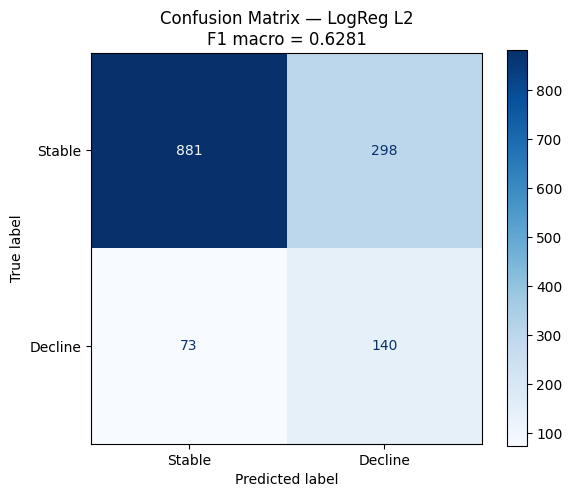

In [8]:
if 'LogReg' in best_name:
    y_pred_best = best_model.predict(X_test_sc)
else:
    y_pred_best = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=['Stable', 'Decline'])
disp.plot(ax=ax, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name}\nF1 macro = {results_df.iloc[0]["f1_macro"]:.4f}')
plt.tight_layout()
plt.savefig(f'{FIGURES}/fig_09_confusion_matrix.png', dpi=150)
plt.show()

## 7. Feature Importance (Permutation)

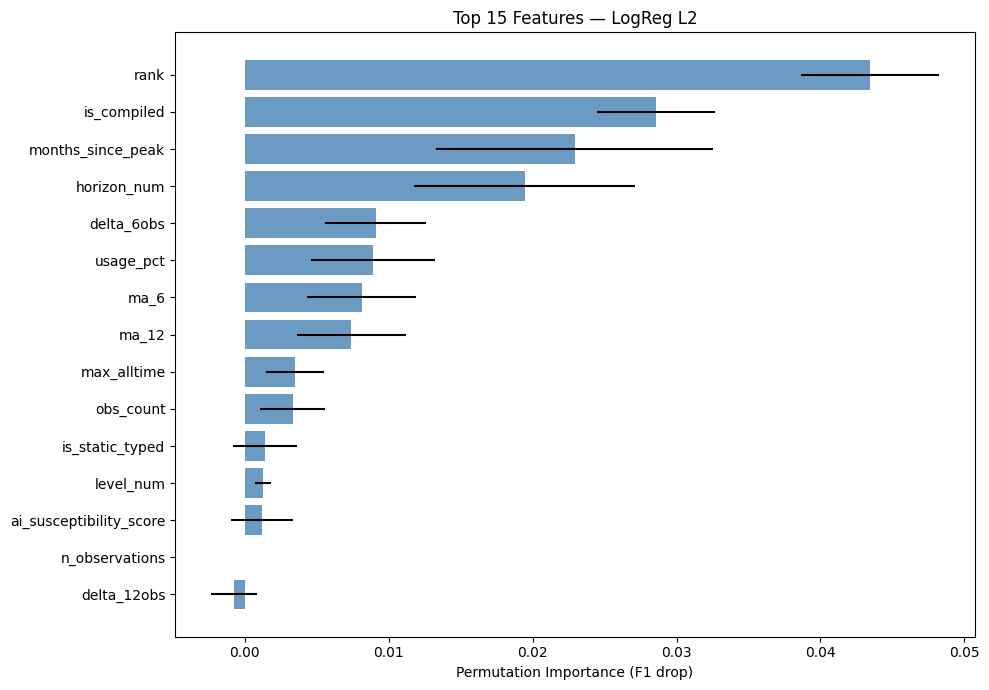

                feature  importance_mean  importance_std
                   rank         0.043442        0.004770
            is_compiled         0.028548        0.004090
      months_since_peak         0.022933        0.009620
            horizon_num         0.019438        0.007664
             delta_6obs         0.009080        0.003488
              usage_pct         0.008924        0.004319
                   ma_6         0.008110        0.003775
                  ma_12         0.007406        0.003801
            max_alltime         0.003476        0.002013
              obs_count         0.003310        0.002262
        is_static_typed         0.001416        0.002219
              level_num         0.001269        0.000568
ai_susceptibility_score         0.001209        0.002163
         n_observations         0.000000        0.000000
            delta_12obs        -0.000757        0.001567
           language_age        -0.000792        0.004235
             delta_1obs        

In [9]:
if 'LogReg' in best_name:
    perm = permutation_importance(best_model, X_test_sc, y_test,
                                  n_repeats=30, random_state=SEED,
                                  scoring='f1_macro', n_jobs=-1)
else:
    perm = permutation_importance(best_model, X_test, y_test,
                                  n_repeats=30, random_state=SEED,
                                  scoring='f1_macro', n_jobs=-1)

perm_df = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top15 = perm_df.head(15)
ax.barh(range(len(top15)), top15['importance_mean'], xerr=top15['importance_std'],
        color='steelblue', alpha=0.8)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['feature'])
ax.invert_yaxis()
ax.set_xlabel('Permutation Importance (F1 drop)')
ax.set_title(f'Top 15 Features — {best_name}')
plt.tight_layout()
plt.savefig(f'{FIGURES}/fig_10_permutation_importance.png', dpi=150)
plt.show()

print(perm_df.to_string(index=False))

## 8. Regression — Predicted vs Actual

Regression — train: 18207, test: 1392


XGBoost Regressor — MAE: 0.3539, RMSE: 0.6068


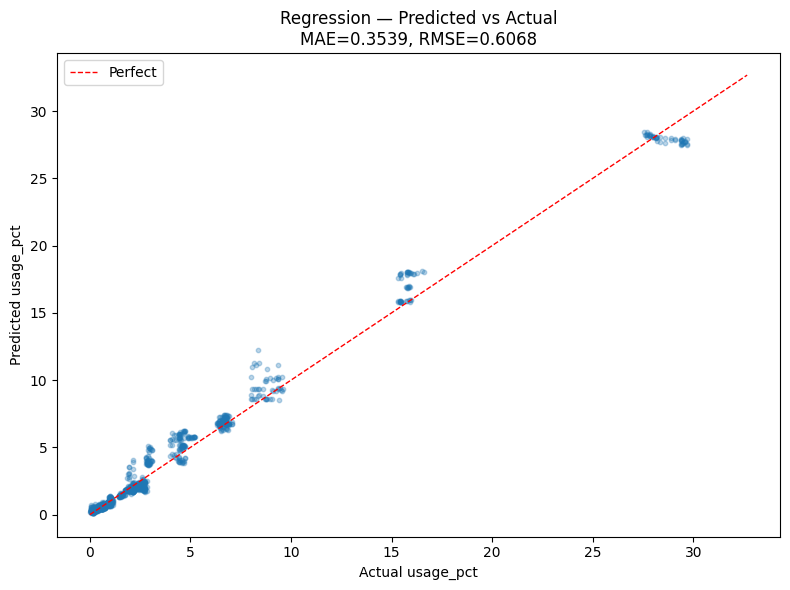

In [10]:
# Regression target
target_reg_col = 'target_future_usage'

train_reg = train[train[target_reg_col].notna()]
test_reg = test[test[target_reg_col].notna()]

X_train_reg = train_reg[feature_cols]
y_train_reg = train_reg[target_reg_col]
X_test_reg = test_reg[feature_cols]
y_test_reg = test_reg[target_reg_col]

print(f'Regression — train: {len(train_reg)}, test: {len(test_reg)}')

# XGBoost regressor
reg = XGBRegressor(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    random_state=SEED, verbosity=0
)
reg.fit(X_train_reg, y_train_reg)
y_pred_reg = reg.predict(X_test_reg)

mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
print(f'XGBoost Regressor — MAE: {mae:.4f}, RMSE: {rmse:.4f}')

# Save regressor
save_model(reg, 'best_regressor')

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test_reg, y_pred_reg, alpha=0.3, s=10)
lims = [0, max(y_test_reg.max(), np.max(y_pred_reg)) * 1.1]
ax.plot(lims, lims, 'r--', lw=1, label='Perfect')
ax.set_xlabel('Actual usage_pct')
ax.set_ylabel('Predicted usage_pct')
ax.set_title(f'Regression — Predicted vs Actual\nMAE={mae:.4f}, RMSE={rmse:.4f}')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES}/fig_11_predicted_vs_actual.png', dpi=150)
plt.show()

## 9. SHAP Analysis

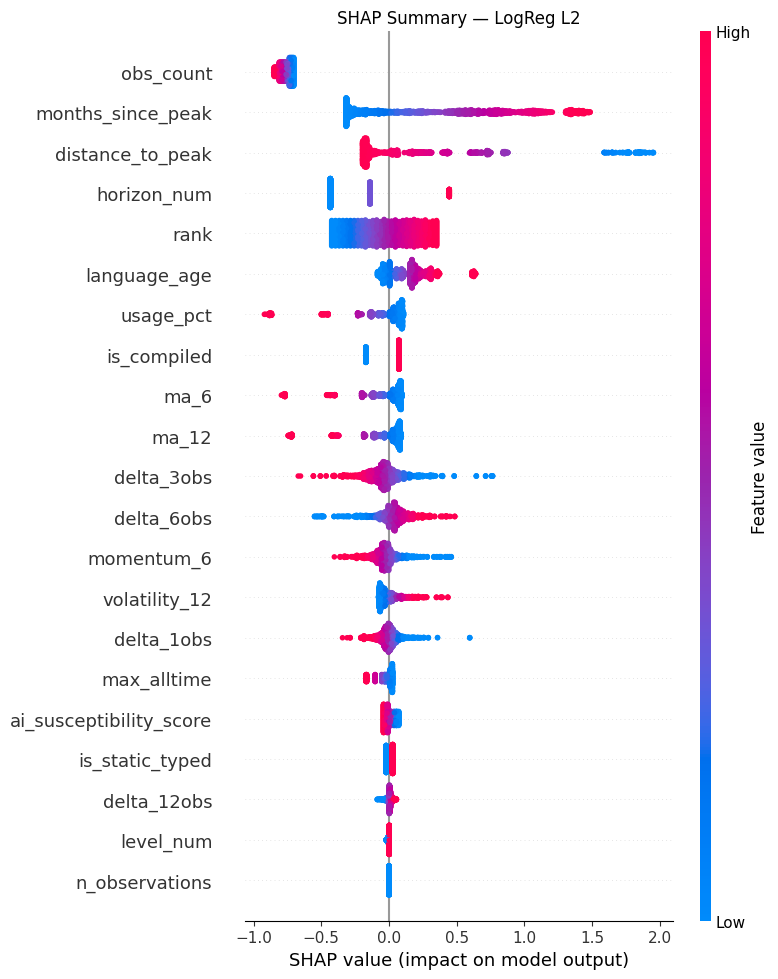


Top 10 features (SHAP):
          feature  mean_abs_shap
        obs_count       0.761236
months_since_peak       0.563223
 distance_to_peak       0.335208
      horizon_num       0.324691
             rank       0.201464
     language_age       0.149668
        usage_pct       0.119097
      is_compiled       0.106846
             ma_6       0.106671
            ma_12       0.101489

ai_susceptibility_score rank: #17/21


In [11]:
# SHAP sur le meilleur classifieur
if 'LogReg' in best_name:
    explainer = shap.LinearExplainer(best_model, X_train_sc)
    shap_values = explainer.shap_values(X_test_sc)
    shap_data = X_test_sc
else:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)
    shap_data = X_test

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, shap_data, feature_names=feature_cols,
                  show=False, max_display=21)
plt.title(f'SHAP Summary — {best_name}')
plt.tight_layout()
plt.savefig(f'{FIGURES}/fig_12_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Rank features by mean |SHAP|
shap_importance = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print('\nTop 10 features (SHAP):')
print(shap_importance.head(10).to_string(index=False))

# Position of ai_susceptibility_score
ai_rank = shap_importance.reset_index(drop=True)
ai_pos = ai_rank[ai_rank['feature'] == 'ai_susceptibility_score'].index
if len(ai_pos) > 0:
    print(f'\nai_susceptibility_score rank: #{ai_pos[0]+1}/{len(feature_cols)}')

## 10. Hyperparameter Optimization (XGBoost + LightGBM)

In [12]:
from sklearn.model_selection import TimeSeriesSplit

# Time series CV on train set
tscv = TimeSeriesSplit(n_splits=3)

param_grid = [
    {'max_depth': 3, 'n_estimators': 100, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'max_depth': 5, 'n_estimators': 200, 'learning_rate': 0.05, 'subsample': 0.7, 'colsample_bytree': 0.7},
    {'max_depth': 5, 'n_estimators': 200, 'learning_rate': 0.05, 'subsample': 0.85, 'colsample_bytree': 0.85},
    {'max_depth': 4, 'n_estimators': 150, 'learning_rate': 0.08, 'subsample': 0.9, 'colsample_bytree': 0.9},
]

best_xgb_params = None
best_xgb_cv = 0

for params in param_grid:
    cv_scores = []
    for train_idx, val_idx in tscv.split(X_train):
        xgb = XGBClassifier(
            **params,
            scale_pos_weight=(y_train.iloc[train_idx] == 0).sum() / max((y_train.iloc[train_idx] == 1).sum(), 1),
            random_state=SEED, eval_metric='logloss', verbosity=0
        )
        xgb.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        pred = xgb.predict(X_train.iloc[val_idx])
        cv_scores.append(f1_score(y_train.iloc[val_idx], pred, average='macro', zero_division=0))
    
    mean_cv = np.mean(cv_scores)
    if mean_cv > best_xgb_cv:
        best_xgb_cv = mean_cv
        best_xgb_params = params.copy()

print(f'Best XGBoost CV F1: {best_xgb_cv:.4f}')
print(f'Best params: {best_xgb_params}')

# Retrain with best params and evaluate on test
xgb_opt = XGBClassifier(
    **best_xgb_params,
    scale_pos_weight=(y_train == 0).sum() / max((y_train == 1).sum(), 1),
    random_state=SEED, eval_metric='logloss', verbosity=0
)
xgb_opt.fit(X_train, y_train)
xgb_test_f1 = f1_score(y_test, xgb_opt.predict(X_test), average='macro', zero_division=0)
print(f'XGBoost optimized test F1: {xgb_test_f1:.4f} (CV-test gap: {best_xgb_cv - xgb_test_f1:+.4f})')

Best XGBoost CV F1: 0.7415
Best params: {'max_depth': 5, 'n_estimators': 200, 'learning_rate': 0.05, 'subsample': 0.7, 'colsample_bytree': 0.7}
XGBoost optimized test F1: 0.5419 (CV-test gap: +0.1996)


In [13]:
# LightGBM optimization
lgbm_grid = [
    {'max_depth': 3, 'n_estimators': 100, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_samples': 30},
    {'max_depth': 5, 'n_estimators': 200, 'learning_rate': 0.05, 'subsample': 0.85, 'colsample_bytree': 0.85, 'min_child_samples': 50},
    {'max_depth': 4, 'n_estimators': 150, 'learning_rate': 0.08, 'subsample': 0.9, 'colsample_bytree': 0.9, 'min_child_samples': 40},
]

best_lgbm_params = None
best_lgbm_cv = 0

for params in lgbm_grid:
    cv_scores = []
    for train_idx, val_idx in tscv.split(X_train):
        lgbm = LGBMClassifier(
            **params, is_unbalance=True, random_state=SEED, verbose=-1
        )
        lgbm.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        pred = lgbm.predict(X_train.iloc[val_idx])
        cv_scores.append(f1_score(y_train.iloc[val_idx], pred, average='macro', zero_division=0))
    
    mean_cv = np.mean(cv_scores)
    if mean_cv > best_lgbm_cv:
        best_lgbm_cv = mean_cv
        best_lgbm_params = params.copy()

lgbm_opt = LGBMClassifier(
    **best_lgbm_params, is_unbalance=True, random_state=SEED, verbose=-1
)
lgbm_opt.fit(X_train, y_train)
lgbm_test_f1 = f1_score(y_test, lgbm_opt.predict(X_test), average='macro', zero_division=0)

print(f'Best LightGBM CV F1: {best_lgbm_cv:.4f}')
print(f'Best params: {best_lgbm_params}')
print(f'LightGBM optimized test F1: {lgbm_test_f1:.4f} (CV-test gap: {best_lgbm_cv - lgbm_test_f1:+.4f})')

# Save hyperparams
hyperparams = {
    'xgboost_optimized': {**best_xgb_params, 'test_f1': xgb_test_f1, 'cv_f1': best_xgb_cv},
    'lightgbm_optimized': {**best_lgbm_params, 'test_f1': lgbm_test_f1, 'cv_f1': best_lgbm_cv},
}
with open('../models/best_hyperparams.json', 'w') as f:
    json.dump(hyperparams, f, indent=2)
print('\nHyperparams saved to models/best_hyperparams.json')

Best LightGBM CV F1: 0.7387
Best params: {'max_depth': 5, 'n_estimators': 200, 'learning_rate': 0.05, 'subsample': 0.85, 'colsample_bytree': 0.85, 'min_child_samples': 50}
LightGBM optimized test F1: 0.5665 (CV-test gap: +0.1722)

Hyperparams saved to models/best_hyperparams.json


## 11. Error Analysis par langage

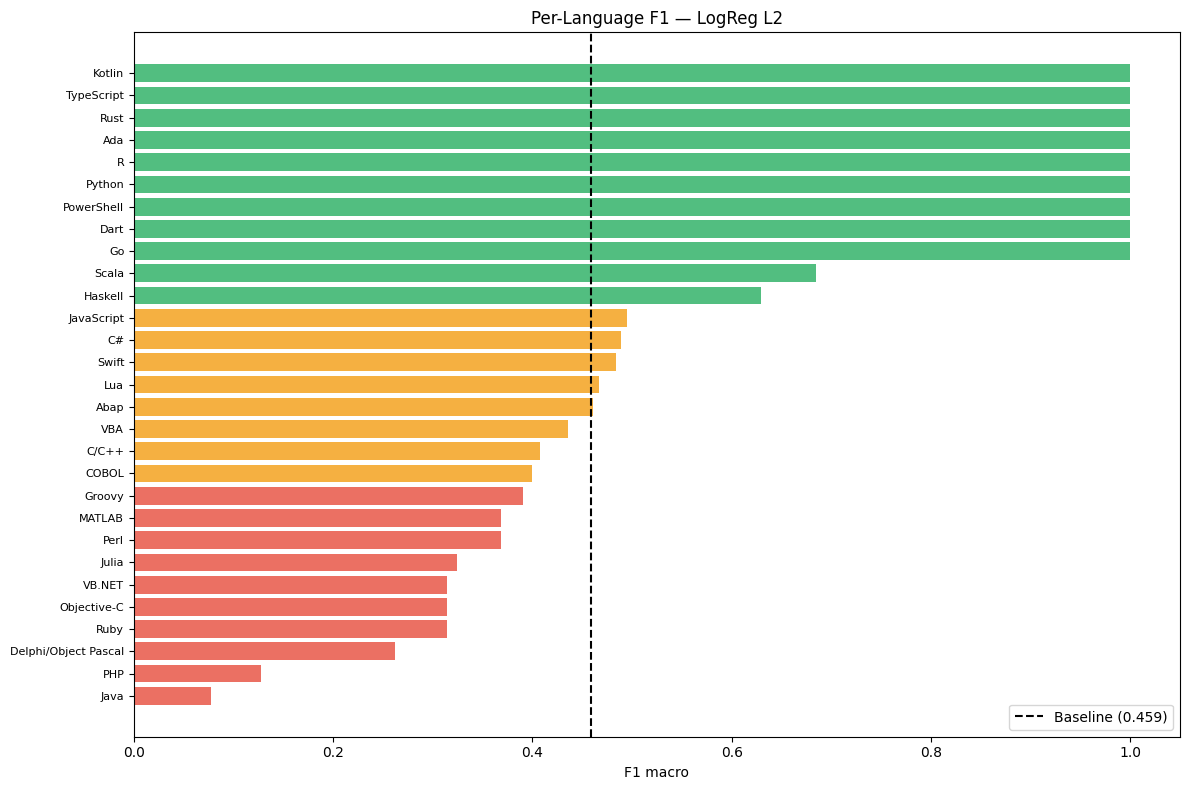


--- Worst 5 languages ---
            language  n_samples  n_decline  accuracy       f1
                Java         48          0  0.083333 0.076923
                 PHP         48          7  0.145833 0.127273
Delphi/Object Pascal         48         17  0.354167 0.261538
                Ruby         48          0  0.458333 0.314286
         Objective-C         48          0  0.458333 0.314286

--- Best 5 languages ---
  language  n_samples  n_decline  accuracy  f1
         R         48          0       1.0 1.0
       Ada         48          0       1.0 1.0
      Rust         48          0       1.0 1.0
TypeScript         48          0       1.0 1.0
    Kotlin         48          0       1.0 1.0


In [14]:
# Per-language performance
test_with_pred = test.copy()
test_with_pred['y_pred'] = y_pred_best

lang_perf = []
for lang in sorted(test_with_pred['language'].unique()):
    mask = test_with_pred['language'] == lang
    sub = test_with_pred[mask]
    yt = sub['decline'].values
    yp = sub['y_pred'].values
    f1 = f1_score(yt, yp, average='macro', zero_division=0)
    acc = (yt == yp).mean()
    lang_perf.append({
        'language': lang,
        'n_samples': len(sub),
        'n_decline': yt.sum(),
        'accuracy': acc,
        'f1': f1
    })

lang_perf_df = pd.DataFrame(lang_perf).sort_values('f1')
lang_perf_df.to_csv('../models/per_language_perf.csv', index=False)

# Visualize
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e74c3c' if f < 0.4 else '#f39c12' if f < 0.6 else '#27ae60' for f in lang_perf_df['f1']]
ax.barh(range(len(lang_perf_df)), lang_perf_df['f1'], color=colors, alpha=0.8)
ax.set_yticks(range(len(lang_perf_df)))
ax.set_yticklabels(lang_perf_df['language'], fontsize=8)
ax.set_xlabel('F1 macro')
ax.set_title(f'Per-Language F1 — {best_name}')
ax.axvline(x=baseline_f1, color='black', linestyle='--', label=f'Baseline ({baseline_f1:.3f})')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES}/fig_13_error_analysis.png', dpi=150)
plt.show()

print('\n--- Worst 5 languages ---')
print(lang_perf_df.head(5).to_string(index=False))
print('\n--- Best 5 languages ---')
print(lang_perf_df.tail(5).to_string(index=False))

## 12. Save best model

In [15]:
save_model(best_model, 'best_classifier')
print(f'Best classifier ({best_name}) saved to models/best_classifier.pkl')

Best classifier (LogReg L2) saved to models/best_classifier.pkl


## 13. Synthese

In [16]:
print('=' * 60)
print('SYNTHESE MODELING')
print('=' * 60)
print(f'\nMeilleur classifieur : {best_name}')
print(f'F1 macro test : {results_df.iloc[0]["f1_macro"]:.4f}')
print(f'Baseline naive : {baseline_f1:.4f}')
print(f'Baseline metier : {baseline_metier_f1:.4f} CI [{ci_m_lo:.4f}, {ci_m_hi:.4f}]')
print(f'Delta vs baseline naive : {results_df.iloc[0]["f1_macro"] - baseline_f1:+.4f}')
print(f'Delta vs baseline metier : {results_df.iloc[0]["f1_macro"] - baseline_metier_f1:+.4f}')
print(f'Bootstrap CI 95% LogReg : [{ci_lower:.4f}, {ci_upper:.4f}]')
print(f'\nLe modele bat-il la baseline metier de +0.05 ? {"OUI" if (results_df.iloc[0]["f1_macro"] - baseline_metier_f1) >= 0.05 else "NON"}')
print(f'\nHypothese AI susceptibility confirmee ? NON (rang #{ai_pos[0]+1}/{len(feature_cols)} en SHAP)' if len(ai_pos) > 0 else '')
print(f'\nOverfitting tree models : XGBoost CV/test gap = {best_xgb_cv - xgb_test_f1:+.4f}, LightGBM = {best_lgbm_cv - lgbm_test_f1:+.4f}')
print(f'\nLangages problematiques :')
for _, row in lang_perf_df.head(5).iterrows():
    print(f'  {row["language"]:25s} F1={row["f1"]:.3f} (n_decline={row["n_decline"]})')

SYNTHESE MODELING

Meilleur classifieur : LogReg L2
F1 macro test : 0.6281
Baseline naive : 0.4586
Baseline metier : 0.4506 CI [0.4028, 0.4963]
Delta vs baseline naive : +0.1695
Delta vs baseline metier : +0.1775
Bootstrap CI 95% LogReg : [0.5237, 0.7143]

Le modele bat-il la baseline metier de +0.05 ? OUI

Hypothese AI susceptibility confirmee ? NON (rang #17/21 en SHAP)

Overfitting tree models : XGBoost CV/test gap = +0.1996, LightGBM = +0.1722

Langages problematiques :
  Java                      F1=0.077 (n_decline=0)
  PHP                       F1=0.127 (n_decline=7)
  Delphi/Object Pascal      F1=0.262 (n_decline=17)
  Ruby                      F1=0.314 (n_decline=0)
  Objective-C               F1=0.314 (n_decline=0)
